<a href="https://colab.research.google.com/github/vinitpatil519/Indicator_Fix/blob/main/HHLL_structural_fix_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HH/HL/LH/LL Indicator — structural fix and diagnostic notebook


In [ ]:
# Install dependencies in Google Colab
!pip -q install yfinance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from dataclasses import dataclass

print("Environment ready.")


Environment ready.


## 1. Exact ATR/EMA helpers



In [ ]:
def rma(s: pd.Series, length: int) -> pd.Series:
    """Wilder's RMA, equivalent in structure to Pine ta.rma()."""
    s = pd.Series(s, dtype="float64")
    out = pd.Series(np.nan, index=s.index, dtype="float64")
    vals = s.to_numpy()

    if len(vals) < length:
        return out

    first = np.nanmean(vals[:length])
    out.iloc[length - 1] = first
    alpha = 1.0 / length

    prev = first
    for i in range(length, len(vals)):
        x = vals[i]
        if np.isnan(x):
            out.iloc[i] = prev
        else:
            prev = alpha * x + (1 - alpha) * prev
            out.iloc[i] = prev
    return out

def true_range(df):
    prev_close = df["close"].shift(1)
    tr = pd.concat([
        df["high"] - df["low"],
        (df["high"] - prev_close).abs(),
        (df["low"] - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr

def add_indicators(df, atr_len=4, ema_fast=50, ema_slow=200):
    df = df.copy()
    tr = true_range(df)
    df["ATR"] = rma(tr, atr_len)
    df["EMA_FAST"] = df["close"].ewm(span=ema_fast, adjust=False, min_periods=ema_fast).mean()
    df["EMA_SLOW"] = df["close"].ewm(span=ema_slow, adjust=False, min_periods=ema_slow).mean()
    return df


## 2. Original logic vs fixed logic


The fixed engine intentionally stores two timestamps for every pivot:
- `pivot_idx`: where the extreme actually occurred
- `confirm_idx`: where the market finally gave enough information to know the pivot


In [ ]:
def original_pine_engine(df, zigzag_period=4, rev_multiplier=1.0):
    """
    Faithful diagnostic port of the uploaded Pine signal state machine.
    IMPORTANT: signal_idx is the actual bar on which Pine knows the pivot.
    plot_idx is where the original Pine label is drawn.
    """
    x = add_indicators(df, atr_len=zigzag_period).reset_index(drop=False)
    x["bar"] = np.arange(len(x))

    search_dir = "high"
    extreme_val = np.nan
    extreme_bar = None
    last_ph = np.nan
    last_pl = np.nan

    trend = "none"
    pending_ll_val = np.nan
    pending_ll_bar = None
    pending_hh_val = np.nan
    pending_hh_bar = None

    pivots = []
    signals = []

    for i in range(len(x)):
        high, low = float(x.at[i, "high"]), float(x.at[i, "low"])
        atr = x.at[i, "ATR"]
        if pd.isna(atr):
            continue
        reversal = float(atr) * rev_multiplier

        if extreme_bar is None:
            extreme_val = high
            extreme_bar = i

        if search_dir == "high":
            if np.isnan(extreme_val) or high > extreme_val:
                extreme_val, extreme_bar = high, i

            if low <= extreme_val - reversal:
                pv, pb = extreme_val, extreme_bar
                tag = "" if np.isnan(last_ph) else ("HH" if pv > last_ph else "LH")
                pivots.append({"pivot_idx": pb, "confirm_idx": i, "type": "High", "tag": tag, "value": pv})

                if tag:
                    if trend == "down":
                        if tag == "HH":
                            if not np.isnan(pending_ll_val):
                                pending_hh_val, pending_hh_bar = pv, pb
                            else:
                                signals.append({"type": "BUY", "pivot_idx": pb, "confirm_idx": i, "plot_idx": pb,
                                                 "tag": tag, "delay_bars": i-pb})
                                trend = "up"
                    else:
                        if tag == "LH":
                            signals.append({"type": "SELL", "pivot_idx": pb, "confirm_idx": i, "plot_idx": pb,
                                             "tag": tag, "delay_bars": i-pb})
                            trend = "down"
                            pending_ll_val, pending_ll_bar = np.nan, None
                        elif tag == "HH":
                            trend = "up"
                last_ph = pv
                search_dir = "low"
                extreme_val, extreme_bar = low, i

        else:
            if np.isnan(extreme_val) or low < extreme_val:
                extreme_val, extreme_bar = low, i

            if high >= extreme_val + reversal:
                pv, pb = extreme_val, extreme_bar
                tag = "" if np.isnan(last_pl) else ("HL" if pv > last_pl else "LL")
                pivots.append({"pivot_idx": pb, "confirm_idx": i, "type": "Low", "tag": tag, "value": pv})

                if tag:
                    if not np.isnan(pending_hh_val):
                        if tag == "LL":
                            signals.append({"type": "SELL", "pivot_idx": pending_hh_bar, "confirm_idx": i, "plot_idx": pending_hh_bar,
                                             "tag": tag, "delay_bars": i-pending_hh_bar})
                            pending_ll_val, pending_ll_bar = pv, i
                            trend = "down"
                        else:  # HL
                            if pending_ll_bar is not None:
                                signals.append({"type": "BUY", "pivot_idx": pending_ll_bar, "confirm_idx": i,
                                                "plot_idx": pending_ll_bar, "tag": tag, "delay_bars": i-pending_ll_bar})
                            else:
                                signals.append({"type": "BUY", "pivot_idx": pb, "confirm_idx": i, "plot_idx": pb,
                                                "tag": tag, "delay_bars": i-pb})
                            trend = "up"
                            pending_ll_val, pending_ll_bar = np.nan, None
                        pending_hh_val, pending_hh_bar = np.nan, None

                    elif trend == "up":
                        if tag == "LL":
                            # THIS IS THE NOISE BUG IN THE UPLOADED SCRIPT:
                            # it explicitly emits BUY on an LL during an up regime.
                            signals.append({"type": "BUY", "pivot_idx": pb, "confirm_idx": i, "plot_idx": pb,
                                             "tag": tag, "delay_bars": i-pb})
                    else:
                        if tag == "LL":
                            pending_ll_val, pending_ll_bar = pv, pb
                            trend = "down"
                        else:  # HL
                            plot_bar = pb if pending_ll_bar is None else pending_ll_bar
                            signals.append({"type": "BUY", "pivot_idx": plot_bar, "confirm_idx": i, "plot_idx": plot_bar,
                                             "tag": tag, "delay_bars": i-plot_bar})
                            trend = "up"
                            pending_ll_val, pending_ll_bar = np.nan, None

                last_pl = pv
                search_dir = "high"
                extreme_val, extreme_bar = high, i

    return pd.DataFrame(pivots), pd.DataFrame(signals)


def fixed_pine_engine(df, zigzag_period=4, rev_multiplier=1.0, bar_close_only=True):
    """
    Structural fix:
      - signal is emitted only on confirmation bar
      - LL in up-regime starts down-regime; never buys it
      - no second sell for a fakeout during an already-down regime
      - reversal ATR is frozen for each ZigZag leg
    """
    x = add_indicators(df, atr_len=zigzag_period).reset_index(drop=False)
    x["bar"] = np.arange(len(x))

    search_dir = "high"
    extreme_val = np.nan
    extreme_bar = None
    leg_atr = np.nan
    last_ph = np.nan
    last_pl = np.nan

    trend = "none"
    pending_ll_val = np.nan
    pending_ll_bar = None
    pending_hh_val = np.nan
    pending_hh_bar = None

    pivots = []
    signals = []

    for i in range(len(x)):
        high, low = float(x.at[i, "high"]), float(x.at[i, "low"])
        atr = x.at[i, "ATR"]
        if pd.isna(atr):
            continue

        if extreme_bar is None:
            extreme_val, extreme_bar, leg_atr = high, i, float(atr)

        if search_dir == "high":
            if high > extreme_val:
                extreme_val, extreme_bar = high, i

            reversal = float(leg_atr) * rev_multiplier
            if low <= extreme_val - reversal:
                pv, pb = extreme_val, extreme_bar
                tag = "" if np.isnan(last_ph) else ("HH" if pv > last_ph else "LH")
                pivots.append({"pivot_idx": pb, "confirm_idx": i, "type": "High", "tag": tag, "value": pv})

                if tag == "LH" and trend != "down":
                    if (not bar_close_only) or True:  # historical bars are confirmed
                        signals.append({"type": "SELL", "pivot_idx": pb, "confirm_idx": i,
                                         "plot_idx": i, "tag": tag, "delay_bars": i-pb})
                    trend = "down"
                    pending_ll_val, pending_ll_bar = np.nan, None
                    pending_hh_val, pending_hh_bar = np.nan, None

                elif tag == "HH":
                    if trend == "down":
                        pending_hh_val, pending_hh_bar = pv, pb
                    else:
                        trend = "up"

                last_ph = pv
                search_dir = "low"
                extreme_val, extreme_bar, leg_atr = low, i, float(atr)

        else:
            if low < extreme_val:
                extreme_val, extreme_bar = low, i

            reversal = float(leg_atr) * rev_multiplier
            if high >= extreme_val + reversal:
                pv, pb = extreme_val, extreme_bar
                tag = "" if np.isnan(last_pl) else ("HL" if pv > last_pl else "LL")
                pivots.append({"pivot_idx": pb, "confirm_idx": i, "type": "Low", "tag": tag, "value": pv})

                if not np.isnan(pending_hh_val):
                    if tag == "HL":
                        signals.append({"type": "BUY", "pivot_idx": pb, "confirm_idx": i,
                                         "plot_idx": i, "tag": tag, "delay_bars": i-pb})
                        trend = "up"
                        pending_ll_val, pending_ll_bar = np.nan, None
                    elif tag == "LL":
                        pending_ll_val, pending_ll_bar = pv, pb
                        trend = "down"
                    pending_hh_val, pending_hh_bar = np.nan, None

                elif tag == "LL":
                    # ROOT FIX: LL is bearish structure, not a buy.
                    pending_ll_val, pending_ll_bar = pv, pb
                    trend = "down"

                elif tag == "HL":
                    if trend in ("down", "none"):
                        signals.append({"type": "BUY", "pivot_idx": pb, "confirm_idx": i,
                                         "plot_idx": i, "tag": tag, "delay_bars": i-pb})
                        trend = "up"
                        pending_ll_val, pending_ll_bar = np.nan, None

                elif tag == "HH":
                    trend = "up"

                last_pl = pv
                search_dir = "high"
                extreme_val, extreme_bar, leg_atr = high, i, float(atr)

    return pd.DataFrame(pivots), pd.DataFrame(signals)


## 3. Diagnostics: prove the lag/noise problem quantitatively

Run this before judging the fix. The most useful metrics are:
- **Median / 90th-percentile signal delay**: bars between the actual extreme and the bar on which the signal became knowable.
- **Backdated-signal gap**: how far the original label is visually displaced into the past.
- **Signals / 100 bars**: a simple noise proxy.
- **Repeated same-side signals**: catches redundant BUY→BUY or SELL→SELL behavior.


In [ ]:
def diagnose(pivots, signals, name="engine"):
    if signals.empty:
        return pd.Series({
            "engine": name, "signals": 0, "signals_per_100_bars": np.nan,
            "median_delay_bars": np.nan, "p90_delay_bars": np.nan,
            "max_delay_bars": np.nan, "same_side_repeats": 0
        })

    s = signals.copy()
    delays = s["delay_bars"].astype(float)
    repeats = int((s["type"] == s["type"].shift(1)).sum())
    return pd.Series({
        "engine": name,
        "signals": len(s),
        "signals_per_100_bars": np.nan,  # filled after data length is known
        "median_delay_bars": delays.median(),
        "p90_delay_bars": delays.quantile(0.90),
        "max_delay_bars": delays.max(),
        "same_side_repeats": repeats
    })

def compare_engines(df, zigzag_period=4, rev_multiplier=1.0):
    op, os = original_pine_engine(df, zigzag_period, rev_multiplier)
    fp, fs = fixed_pine_engine(df, zigzag_period, rev_multiplier)
    a = diagnose(op, os, "ORIGINAL")
    b = diagnose(fp, fs, "FIXED")
    a["signals_per_100_bars"] = 100 * a["signals"] / len(df)
    b["signals_per_100_bars"] = 100 * b["signals"] / len(df)
    return pd.DataFrame([a, b]), op, os, fp, fs

# Example usage:
# metrics, original_pivots, original_signals, fixed_pivots, fixed_signals = compare_engines(df, 4, 1.0)
# display(metrics)


## 4. Load real test data



In [ ]:
# SAMPLE — change these to your teammate's market/timeframe.
symbol = "GC=F"       # Gold futures proxy
period = "60d"
interval = "15m"

df = yf.download(symbol, period=period, interval=interval, progress=False, auto_adjust=False)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.columns = [str(c).lower() for c in df.columns]
df = df[["open", "high", "low", "close"]].dropna().copy()

print(f"Loaded {len(df):,} bars for {symbol} @ {interval}")
df.head()


Loaded 4,597 bars for GC=F @ 15m


,open,high,low,close
Datetime,,,,
2026-06-08 04:00:00+00:00,4342.000000,4344.500000,4337.799805,4343.399902
2026-06-08 04:15:00+00:00,4343.299805,4346.399902,4340.200195,4344.000000
2026-06-08 04:30:00+00:00,4344.299805,4344.600098,4331.799805,4331.799805
2026-06-08 04:45:00+00:00,4332.200195,4338.000000,4331.799805,4337.200195
2026-06-08 05:00:00+00:00,4337.100098,4340.100098,4328.600098,4328.600098


In [ ]:
# Run the comparison
ZZ_PERIOD = 4
REV_MULT = 1.0

metrics, original_pivots, original_signals, fixed_pivots, fixed_signals = compare_engines(
    df, zigzag_period=ZZ_PERIOD, rev_multiplier=REV_MULT
)

display(metrics)

print("\nOriginal signals:")
display(original_signals.tail(15) if not original_signals.empty else original_signals)

print("\nFixed signals:")
display(fixed_signals.tail(15) if not fixed_signals.empty else fixed_signals)


,engine,signals,signals_per_100_bars,median_delay_bars,p90_delay_bars,max_delay_bars,same_side_repeats
0,ORIGINAL,908,19.752012,1.0,4.0,12.0,197
1,FIXED,481,10.463346,1.0,2.0,23.0,113



Original signals:


,type,pivot_idx,confirm_idx,plot_idx,tag,delay_bars
893,SELL,4533,4534,4533,LH,1
894,BUY,4537,4542,4537,HL,5
895,SELL,4546,4547,4546,LH,1
896,BUY,4559,4562,4559,HL,3
897,BUY,4563,4564,4563,LL,1
898,BUY,4573,4573,4573,LL,0
899,SELL,4573,4574,4573,LH,1
900,BUY,4574,4579,4574,HL,5
901,SELL,4580,4580,4580,LH,0
902,BUY,4580,4583,4580,HL,3



Fixed signals:


,type,pivot_idx,confirm_idx,plot_idx,tag,delay_bars
466,BUY,4471,4476,4476,HL,5
467,SELL,4481,4483,4483,LH,2
468,BUY,4491,4493,4493,HL,2
469,SELL,4494,4494,4494,LH,0
470,BUY,4494,4495,4495,HL,1
471,BUY,4504,4505,4505,HL,1
472,BUY,4525,4526,4526,HL,1
473,SELL,4536,4537,4537,LH,1
474,BUY,4541,4542,4542,HL,1
475,SELL,4546,4547,4547,LH,1


## 5. Plot: original backdated labels vs fixed live/confirmation labels

This is the key visual check.

**Yellow/orange markers are the actual confirmation bars.** The fixed Buy/Sell labels are plotted there. The original engine records where Pine places its label separately (`plot_idx`) so you can see the visual-vs-actionable gap.


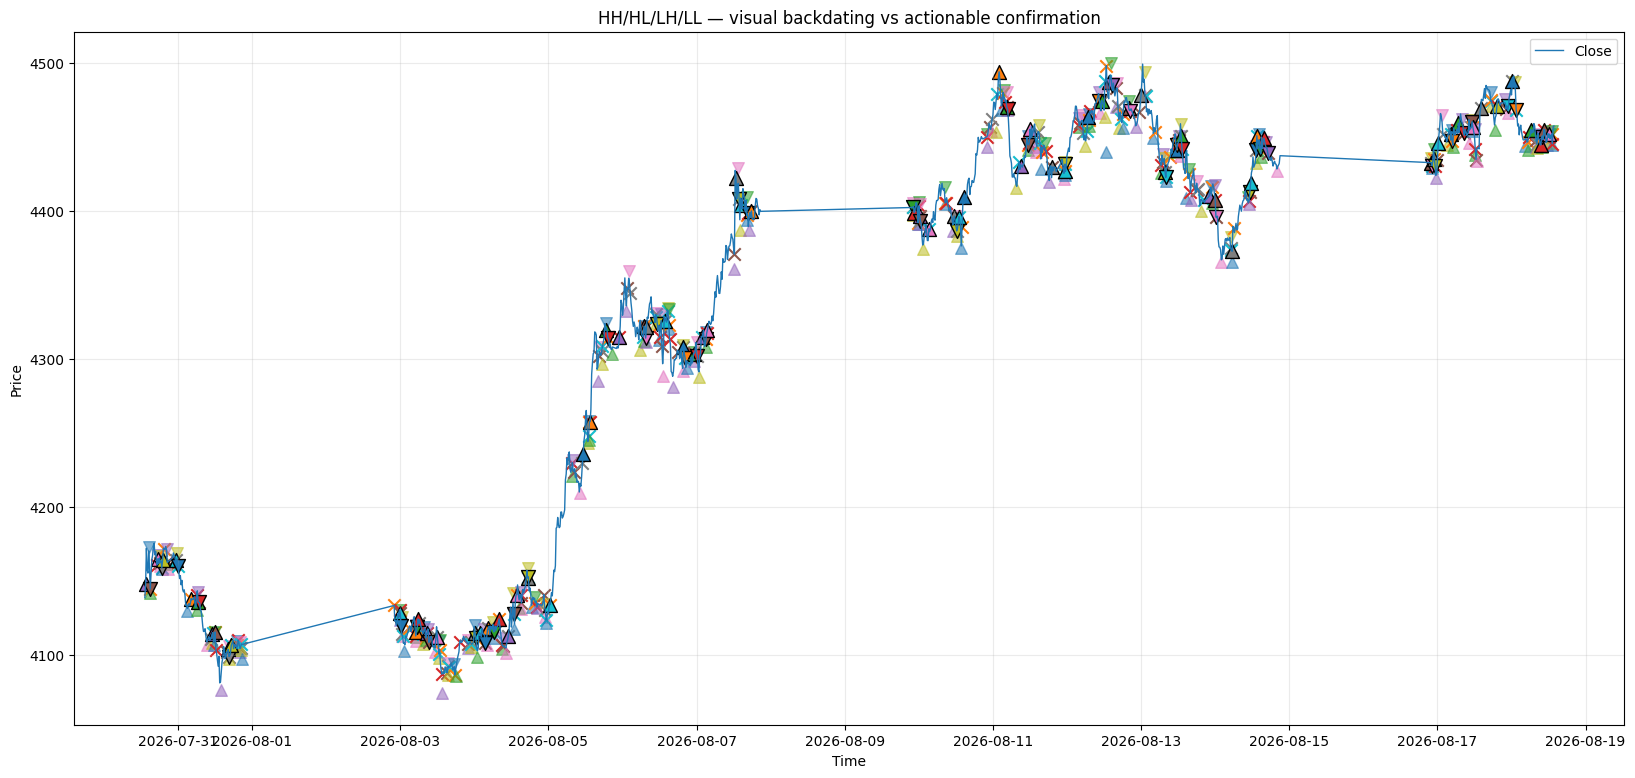

In [ ]:
def plot_comparison(df, original_signals, fixed_signals, max_bars=1200):
    d = df.tail(max_bars).copy()
    start = len(df) - len(d)

    plt.figure(figsize=(20, 9))
    plt.plot(d.index, d["close"], linewidth=1, label="Close")

    if "EMA_FAST" in d:
        plt.plot(d.index, d["EMA_FAST"], linewidth=1, label="EMA 50")
    if "EMA_SLOW" in d:
        plt.plot(d.index, d["EMA_SLOW"], linewidth=1, label="EMA 200")

    def idx_to_date(idx):
        return df.index[int(idx)]

    # Original visual label positions (backdated)
    if not original_signals.empty:
        for _, r in original_signals.iterrows():
            if int(r["plot_idx"]) < start:
                continue
            x = idx_to_date(r["plot_idx"])
            y = df["high"].iloc[int(r["plot_idx"])] if r["type"] == "SELL" else df["low"].iloc[int(r["plot_idx"])]
            plt.scatter([x], [y], marker="v" if r["type"] == "SELL" else "^",
                        s=70, alpha=0.55, label="Original label" if _ == original_signals.index[0] else None)

            # Actual confirmation bar for the same original event
            c = int(r["confirm_idx"])
            if c >= start:
                xc = idx_to_date(c)
                yc = df["close"].iloc[c]
                plt.scatter([xc], [yc], marker="x", s=80,
                            label="Original confirmation" if _ == original_signals.index[0] else None)

    # Fixed signal labels at confirmation
    if not fixed_signals.empty:
        for _, r in fixed_signals.iterrows():
            c = int(r["confirm_idx"])
            if c < start:
                continue
            x = idx_to_date(c)
            y = df["close"].iloc[c]
            plt.scatter([x], [y], marker="^" if r["type"] == "BUY" else "v",
                        s=100, edgecolors="black",
                        label="FIXED signal" if _ == fixed_signals.index[0] else None)

    plt.title("HH/HL/LH/LL — visual backdating vs actionable confirmation")
    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()

plot_comparison(df, original_signals, fixed_signals)


## 6. Optional: inspect every fixed signal

`pivot_idx` tells you the swing extreme that caused the structure.
`confirm_idx` is when the market actually supplied enough information to know that structure.
`plot_idx` is intentionally equal to `confirm_idx` in the fixed engine.

That separation is the main anti-lag correction.


In [ ]:
if not fixed_signals.empty:
    sig_view = fixed_signals.copy()
    sig_view["pivot_time"] = sig_view["pivot_idx"].apply(lambda i: df.index[int(i)])
    sig_view["confirmation_time"] = sig_view["confirm_idx"].apply(lambda i: df.index[int(i)])
    sig_view["confirmation_price"] = sig_view["confirm_idx"].apply(lambda i: df["close"].iloc[int(i)])
    display(sig_view[[
        "type", "tag", "pivot_idx", "pivot_time",
        "confirm_idx", "confirmation_time",
        "confirmation_price", "delay_bars"
    ]])
else:
    print("No signals for this sample/config.")


,type,tag,pivot_idx,pivot_time,confirm_idx,confirmation_time,confirmation_price,delay_bars
0,SELL,LH,5,2026-06-08 05:15:00+00:00,6,2026-06-08 05:30:00+00:00,4312.700195,1
1,BUY,HL,8,2026-06-08 06:00:00+00:00,9,2026-06-08 06:15:00+00:00,4330.899902,1
2,BUY,HL,24,2026-06-08 10:00:00+00:00,26,2026-06-08 10:30:00+00:00,4329.200195,2
3,BUY,HL,45,2026-06-08 15:15:00+00:00,45,2026-06-08 15:15:00+00:00,4354.799805,0
4,SELL,LH,57,2026-06-08 18:15:00+00:00,58,2026-06-08 18:30:00+00:00,4360.899902,1
...,...,...,...,...,...,...,...,...
476,BUY,HL,4565,2026-08-18 06:00:00+00:00,4566,2026-08-18 06:15:00+00:00,4454.899902,1
477,BUY,HL,4579,2026-08-18 09:30:00+00:00,4579,2026-08-18 09:30:00+00:00,4444.500000,0
478,SELL,LH,4580,2026-08-18 09:45:00+00:00,4580,2026-08-18 09:45:00+00:00,4449.700195,0
479,BUY,HL,4582,2026-08-18 10:15:00+00:00,4583,2026-08-18 10:30:00+00:00,4455.000000,1
